In [ ]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(cowplot)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(msigdbr)
library(tidyverse)
library(ggpubr)
library(rstatix)
library(ggprism)
library(reshape2)
library(Seurat)
library(ggplot2)
library(cowplot)
library(tidyverse)
library(dplyr)
library(Seurat)
library(ggplot2)
library(patchwork)
library(ggsci)
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)
library(scCustomize)
library(ggplot2)
library(ggforce)
library(dplyr)
library(ggrepel)
library(patchwork)
library(ggpubr)
library(export)
library(org.Mm.eg.db)#
library("clusterProfiler")
library(biomaRt)
library(tidyverse)
library(limma)
library(IOBR)
library(fgsea)
library(Seurat)
library(Seurat)
library(ggplot2)
library(dplyr)
library(stringr)
library(DESeq2)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
#library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)
library("spatstat.geom")
library(Seurat)
library(Rcpp)
library(harmony)
library(stringr)
library(dplyr)
library(patchwork)
library(ggplot2)
library(ggpubr)
library(reshape2)
library(scales)
library(ggsignif)
library(corrplot)
library(edgeR)
library(ggplot2)
library(FactoMineR)
library(factoextra)  
library(corrplot)   
library(pheatmap)
library(tidyverse)
library(clusterProfiler)
library(org.Hs.eg.db)  
library(GSEABase)    
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)###

In [2]:
setwd("./04fig3/")

In [3]:
sp <- readRDS("./merge_red.RDS")

In [7]:
sp <- ScaleData(sp)

Centering and scaling data matrix



In [303]:
sp

An object of class Seurat 
24382 features across 145127 samples within 1 assay 
Active assay: RNA (24382 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

In [9]:
###fig1 deg
area <- c("GCL","Optic nerve","Cornea&conj","INL","Len","ONL","Iris","CB","Muscle","RPE")

In [10]:
Idents(sp) <- as.factor(sp@meta.data$group)
n=0
for(i in area){
    n=n+1
    sp1 <- subset(sp,subset =area==i)
    sp1 <- ScaleData(sp1, features = rownames(sp1))
    deg <- FindMarkers(sp1,`ident.1` = "RIR",`ident.2` = "Sham",slot = "scale.data")
    deg$divi_area <- i
    deg$gene <- rownames(deg)
    if(n==1){
        deg1 <- deg
    }
    else{
        deg1 <- rbind(deg1,deg)
    }
}

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix

Centering and scaling data matrix



In [11]:
colnames(deg1) <- str_replace(colnames(deg1),"divi_area","cluster")

In [ ]:
deg2 <- deg1[which(abs(deg1$avg_log2FC)>1&deg1$p_val_adj<0.05),]

In [230]:
mm <- as.data.frame(table(deg2$cluster))
colnames(mm) <- c("area","num")
order <- as.character(mm[order(-mm$num),]$area)

In [298]:
mm1 <- mm[order(-mm$num),]


In [300]:
sp@meta.data$deg_num <- 0
for(i in unique(mm1$area)){
    sp@meta.data[which(sp@meta.data$area==i),]$deg_num <- mm1[which(mm1$area==i),]$num
}

In [302]:
saveRDS(sp,"./merge_red.RDS")

In [232]:
saveRDS(deg2,"deg.RDS")

In [233]:
area <-  order
area

[1] "GCL"         "Len"         "Cornea&conj" "INL"         "Optic nerve"
 [6] "CB"          "Iris"        "ONL"         "RPE"         "Muscle"

In [234]:
deg2$cluster <- factor(deg2$cluster,levels = area)

In [235]:
mer <- deg2

In [236]:
mer$label <- "NA"
mer[which(mer$avg_log2FC>0),]$label <- "SigUp"
mer[which(mer$avg_log2FC<0),]$label <- "SigDown"

In [237]:
table(mer$cluster)


        GCL         Len Cornea&conj         INL Optic nerve          CB 
        731         346         258         251         205         153 
       Iris         ONL         RPE      Muscle 
        126         116          22          18 

In [238]:
markers <- mer %>% group_by(cluster) %>% top_n(n = 3, wt = avg_log2FC)
markers1 <- mer %>% group_by(cluster) %>% top_n(n = 3, wt = -avg_log2FC)

In [239]:
top10sig <- rbind(markers,markers1)

In [240]:
mer$size <- case_when(!(mer$gene %in% top10sig$gene)~ 1,
mer$gene %in% top10sig$gene ~ 2)

dt <- filter(mer,size==1)
head(dt)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,label,size
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<dbl>
Calb2,5.845826e-203,-2.063934,0.153,0.484,1.425329e-198,GCL,Calb2,SigDown,1
Snap25,4.849852e-158,-1.401763,0.330,0.635,1.182491e-153,GCL,Snap25,SigDown,1
Apoe,5.308070e-154,2.789167,0.456,0.174,1.294214e-149,GCL,Apoe,SigUp,1
Lyz2,1.469169e-135,4.267192,0.258,0.041,3.582128e-131,GCL,Lyz2,SigUp,1
Rab3a,4.531851e-132,-1.400065,0.288,0.554,1.104956e-127,GCL,Rab3a,SigDown,1
Pcp4,8.680359e-131,-1.419153,0.230,0.503,2.116445e-126,GCL,Pcp4,SigDown,1


In [ ]:
p <- ggplot()+geom_jitter(data = dt,
aes(x = cluster, y = avg_log2FC, color = label,fill=label,alpha=0.7),
size = 0.85,
width =0.4)+
geom_jitter(data = top10sig,
aes(x = cluster, y = avg_log2FC, color = label,fill=label,alpha=0.7),
size = 4,
width =0.4)+scale_x_discrete()
p

In [ ]:
dfbar<-data.frame(x=c(1,2,3,4,5,6,7,8,9,10),
y=c(12,9,6,4,12,10,10,5,5,5))
dfbar1<-data.frame(x=c(1,2,3,4,5,6,7,8,9,10),
y=c(-3,-6,-4,-4,-11.5,-6,-10,-3,-3,-3))
p1 <- ggplot()+
geom_col(data = dfbar,
mapping = aes(x = x,y = y),
fill = "#dcdcdc",alpha = 0.4)+
geom_col(data = dfbar1,
mapping = aes(x = x,y = y),
fill = "#dcdcdc",alpha = 0.4)
p1

In [ ]:

p2 <- ggplot()+
geom_col(data = dfbar,
mapping = aes(x = x,y = y),
fill = "#dcdcdc",alpha = 0.4)+
geom_col(data = dfbar1,
mapping = aes(x = x,y = y),
fill = "#dcdcdc",alpha = 0.4)+geom_jitter(data = dt,
aes(x = cluster, y = avg_log2FC, color = label,fill=label),
size = 1,width =0.2)+
geom_jitter(data = top10sig,
aes(x = cluster, y = avg_log2FC, color = label,fill=label),
size = 3,width =0.2)+scale_x_discrete()
p2

In [270]:
dfcol<-data.frame(x=c(1:10),
y=0,
label=c("GCL","Optic nerve","Len","INL","Cornea&conj","CB","ONL","Iris","RPE","Muscle"))
mycol <- c("#440154", "#46337E", "#365C8A", "#277F8E", "#1FA187", 
                   "#4AC16D", "#9FDA3A", "#FDE725", "#FCAF16", "#E75F1C")
my_colors <- colorRampPalette(c("#5e3c99", "#f7f7f7", "#1b9e77"))(10)
my_colors

[1] "#5E3C99" "#8065AD" "#A28FC2" "#C3B8D7" "#E6E2EC" "#DEEDE8" "#ADD9CC"
 [8] "#7CC5AF" "#4BB193" "#1B9E77"

In [ ]:
p3 <- p2+ geom_tile(data = dfcol,
aes(x=x,y=y),
height=0.4,
color="black",
fill= my_colors,
alpha= 0.6,
show.legend = F)
p3

In [272]:
area

[1] "GCL"         "Len"         "Cornea&conj" "INL"         "Optic nerve"
 [6] "CB"          "Iris"        "ONL"         "RPE"         "Muscle"

In [273]:
cols2<- c('GCL'="#5E3C99",'Len'="#8065AD",'Cornea&conj'="#A28FC2",'INL'="#C3B8D7",'Optic nerve'="#E6E2EC",'CB'="#DEEDE8",'Iris'="#ADD9CC",'ONL'="#7CC5AF",'RPE'="#4BB193",'Muscle'="#1B9E77")

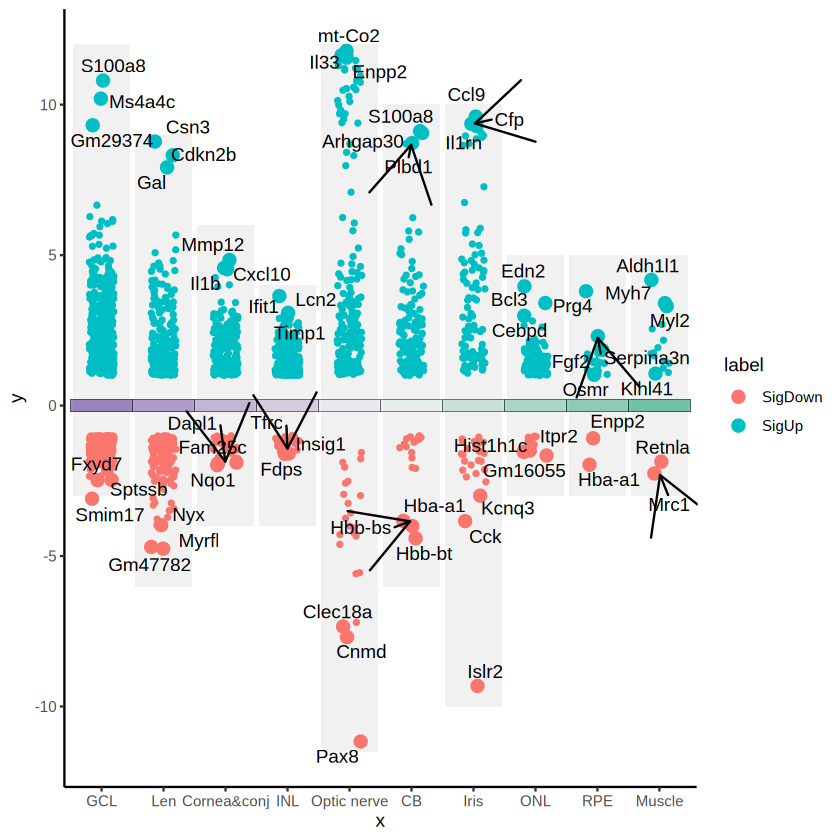

In [274]:
p4<-p3+theme_classic()+geom_text_repel(data=top10sig,
aes(x=cluster,y=avg_log2FC,label=gene),force= 3,arrow=arrow(length = unit(0.1, "npc"),
type="open",ends="last"))
p4

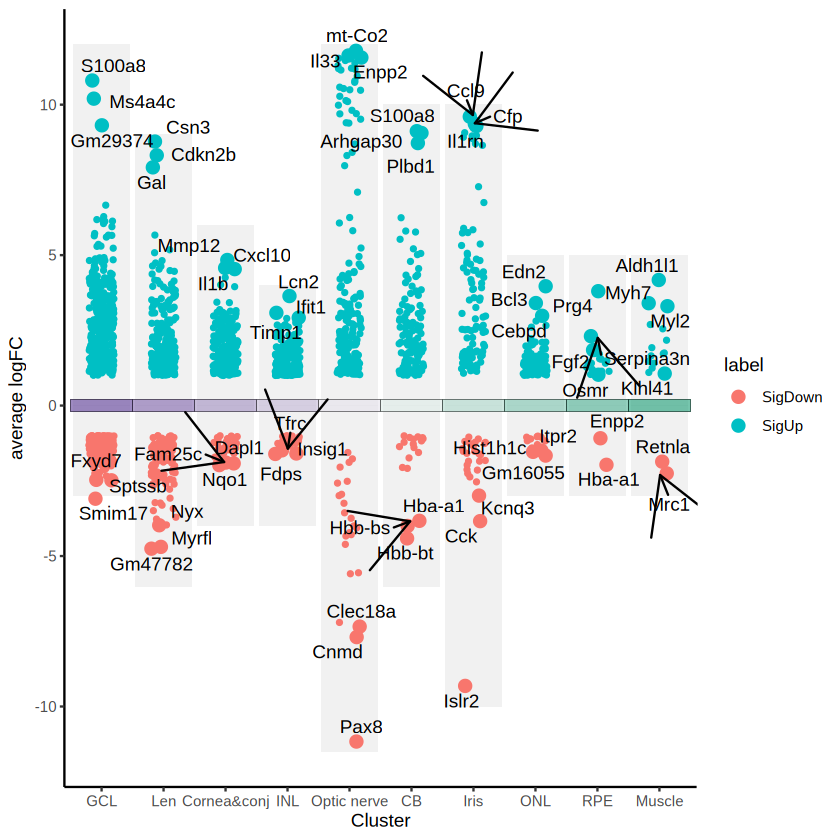

In [276]:
p5<-p4+labs(x="Cluster",y="average logFC")
p5

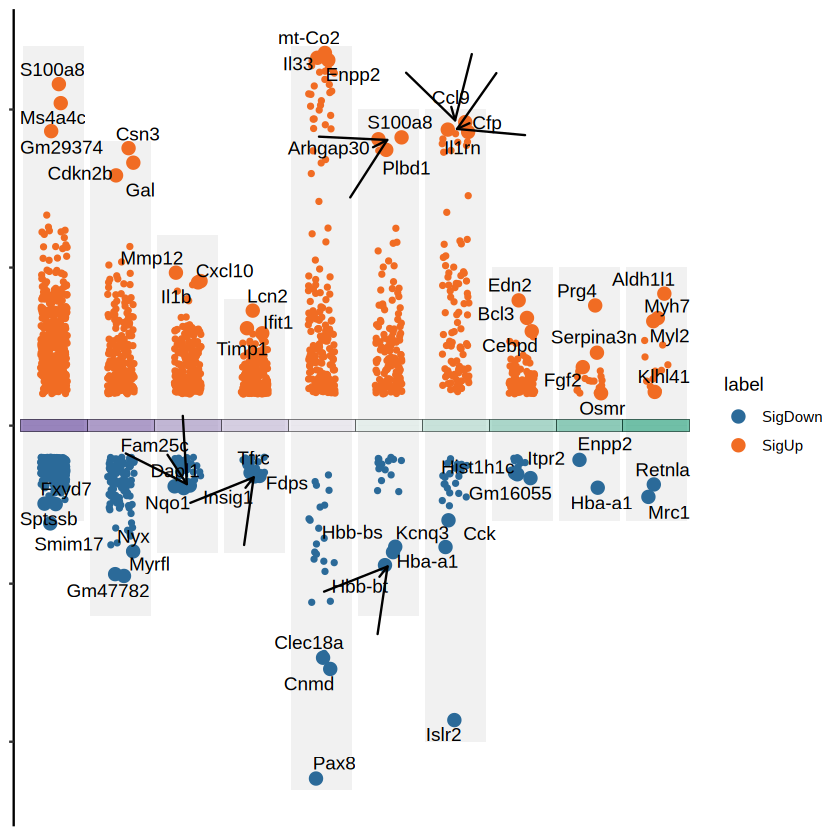

In [277]:
p6 <- p5+scale_colour_manual(values = c("#2b6a99",'#f16c23'))+scale_fill_manual(values = c("#2b6a99",'#f16c23'))+theme(axis.text.x = element_blank(),
             axis.text.y = element_blank(),
             axis.title.x = element_blank(),
             axis.title.y = element_blank())+
theme(axis.text.x = element_blank(),axis.line.x= element_blank(),axis.ticks.x=element_blank()) 
p6

In [278]:
m <- as.data.frame(table(deg2$cluster))
colnames(m) <- c("area","deg")

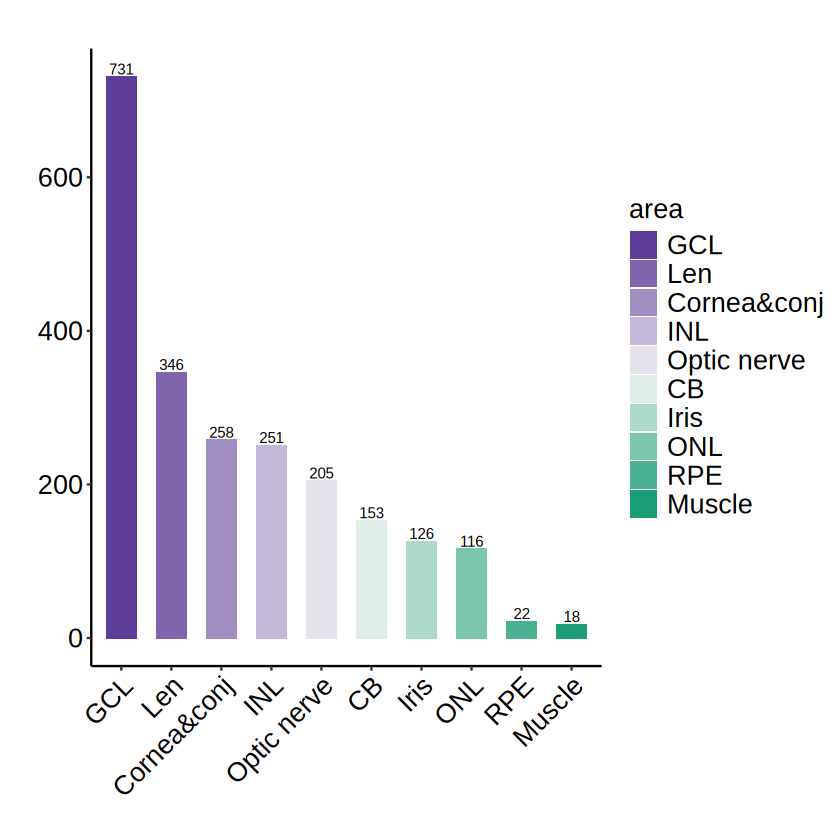

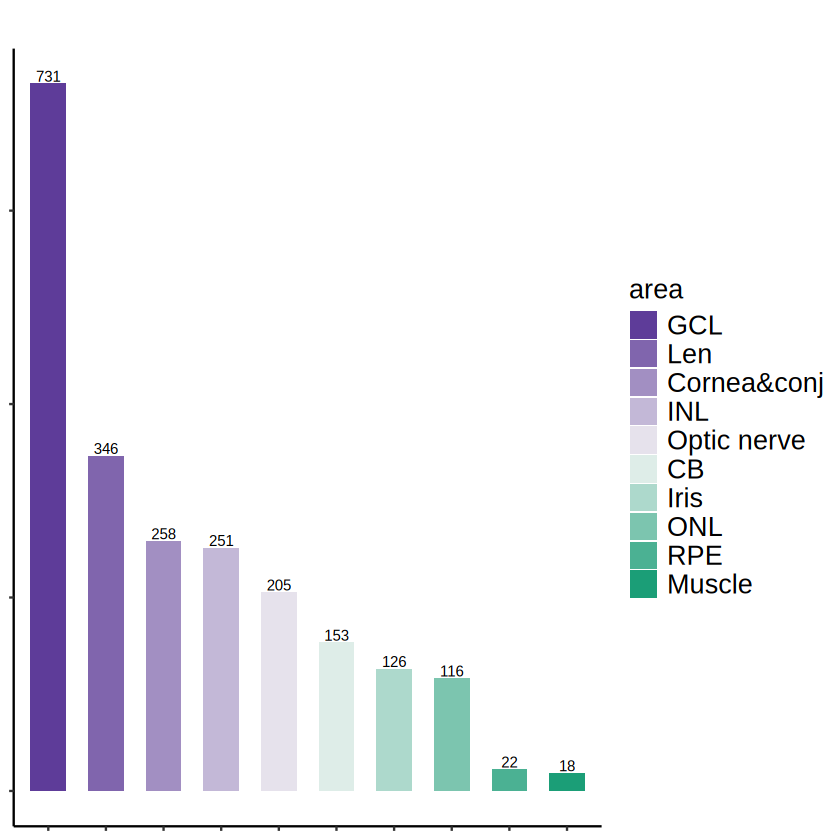

In [279]:
p1 <- ggplot(m, mapping = aes(y=deg,x=area,fill=area))+geom_bar(stat='identity',width = 0.6)+
labs(x = "",y = '',title = "") +theme(axis.title =element_text(size = 16),axis.text =element_text(size = 14, color = 'black'))+
theme(
    plot.title= element_text(color = 'black', size   = 20, hjust = 0.5),
    plot.subtitle = element_text(color = 'black', size   = 16,hjust = 0.5),
    plot.caption  = element_text(color = 'black', size   = 16,face = 'italic', hjust = 1),
    axis.text.x   = element_text(color = 'black', size = 16, angle = 45,hjust = 1),
    axis.text.y   = element_text(color = 'black', size = 16, angle = 0),
    axis.title.x  = element_text(color = 'black', size = 16, angle = 0),
    axis.title.y  = element_text(color = 'black', size = 16, angle = 90),
    legend.title  = element_text(color = 'black', size  = 16),
    legend.text   = element_text(color = 'black', size   = 16),
    axis.line.y = element_line(color = 'black', linetype = 'solid'),
    axis.line.x = element_line (color = 'black',linetype = 'solid'), 
    panel.background=element_rect(fill="white"))+scale_fill_manual(values =cols2)+geom_text(aes(label=deg),vjust= -0.2,color="black",position=position_dodge(.9),size=3)
p1
p2 <- p1+theme(axis.text.x = element_blank(),
             axis.text.y = element_blank(),
             axis.title.x = element_blank(),
             axis.title.y = element_blank())
p2

In [284]:
break_start <- 350   
break_end   <- 700  

In [285]:
library(ggbreak)

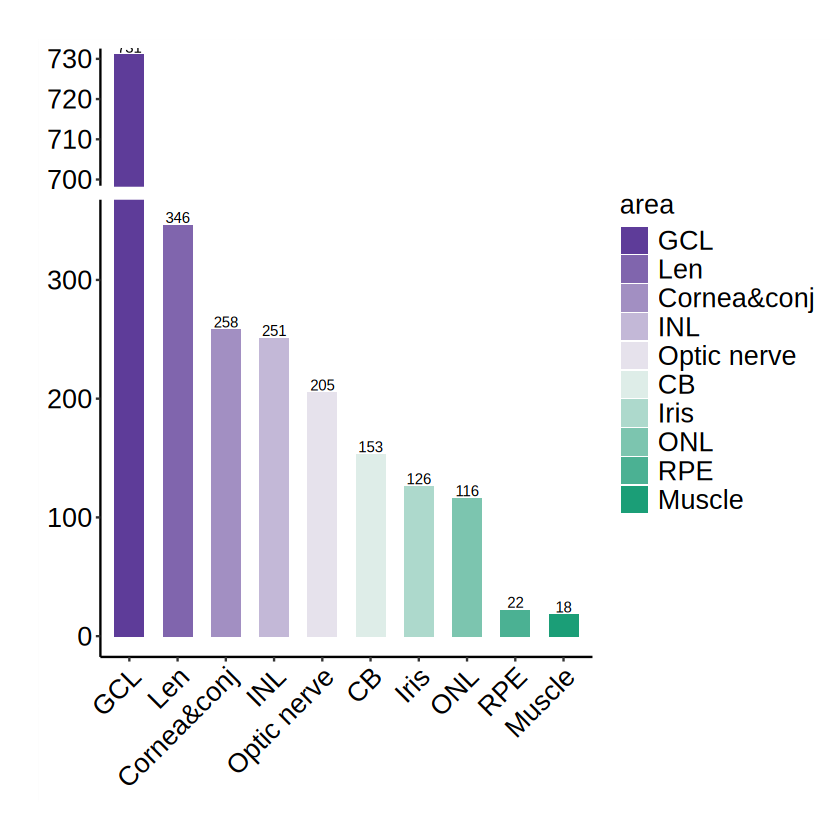

In [286]:
p1 <- ggplot(m, aes(y = deg, x = area, fill = area)) +
  geom_bar(stat = 'identity', width = 0.6) +
  labs(x = "", y = '', title = "") +
  theme(axis.title = element_text(size = 16),
        axis.text = element_text(size = 14, color = 'black'),
        plot.title = element_text(color = 'black', size = 20, hjust = 0.5),
        plot.subtitle = element_text(color = 'black', size = 16, hjust = 0.5),
        plot.caption = element_text(color = 'black', size = 16, face = 'italic', hjust = 1),
        axis.text.x = element_text(color = 'black', size = 16, angle = 45, hjust = 1),
        axis.text.y = element_text(color = 'black', size = 16, angle = 0),
        axis.title.x = element_text(color = 'black', size = 16, angle = 0),
        axis.title.y = element_text(color = 'black', size = 16, angle = 90),
        legend.title = element_text(color = 'black', size = 16),
        legend.text = element_text(color = 'black', size = 16),
        axis.line.y = element_line(color = 'black', linetype = 'solid'),
        axis.line.x = element_line(color = 'black', linetype = 'solid'), 
        panel.background = element_rect(fill = "white")) +
  scale_fill_manual(values = cols2) +
  geom_text(aes(label = deg), 
            vjust = -0.2,  
            color = "black", 
            position = position_dodge(.9), 
            size = 3) +
  # 添加 Y 轴断裂
  scale_y_break(breaks = c(break_start, break_end),
                scales = 0.3,        
                space = 0.2)         

p1

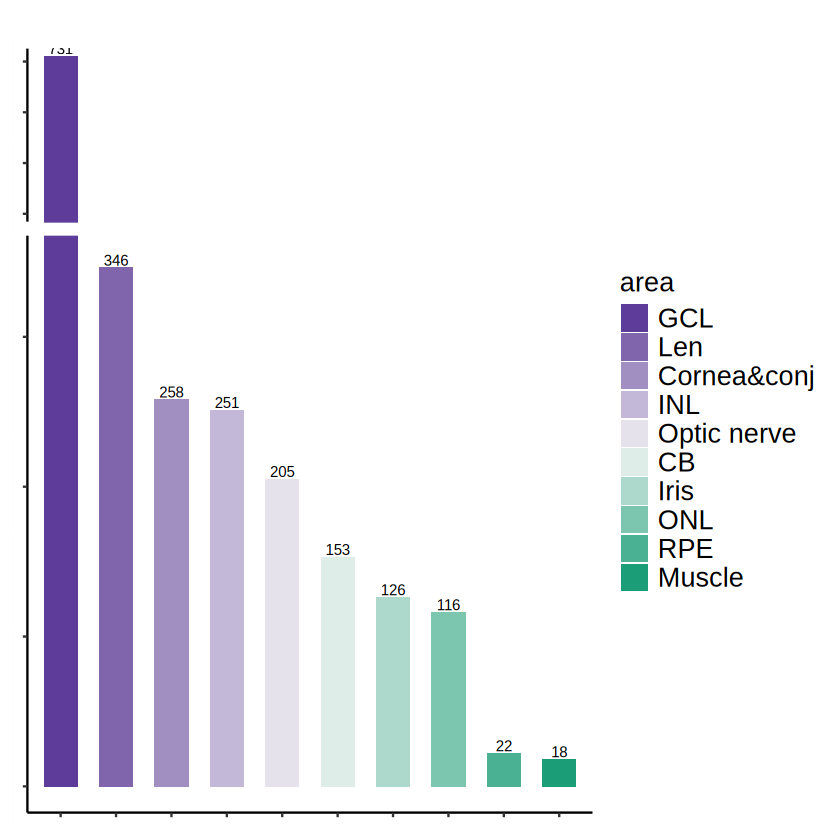

In [287]:
p2 <- p1+theme(axis.text.x = element_blank(),
             axis.text.y = element_blank(),
             axis.title.x = element_blank(),
             axis.title.y = element_blank())
p2

In [ ]:
p3 <- p6%>%insert_top(p2,height = 0.4)
p3

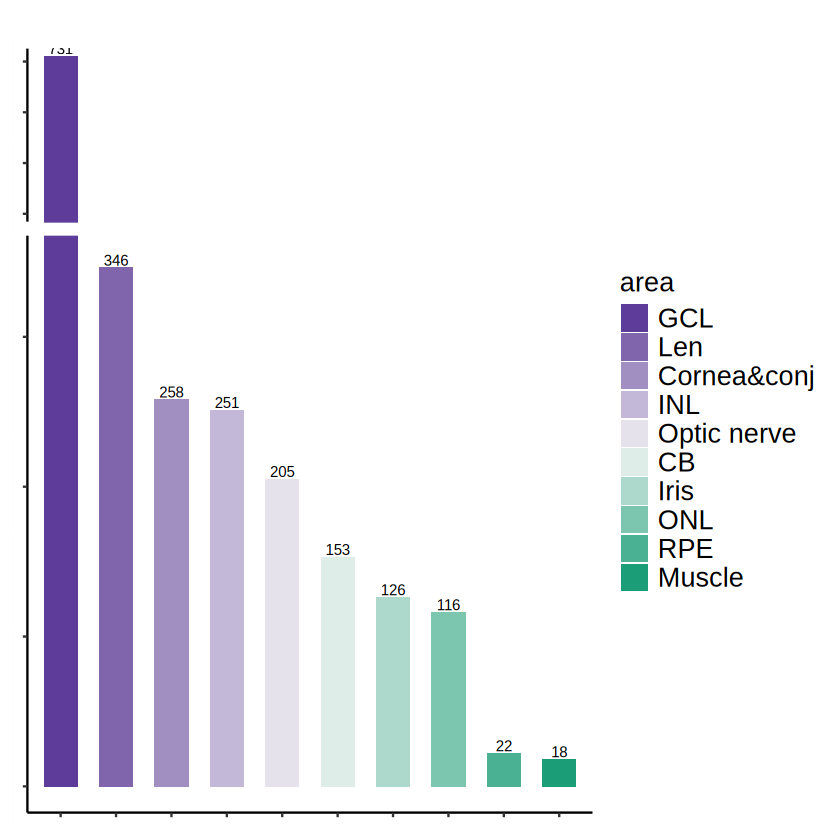

In [291]:
p2
ggsave("STST_numdeg.pdf",p2,width = 6,height = 4)

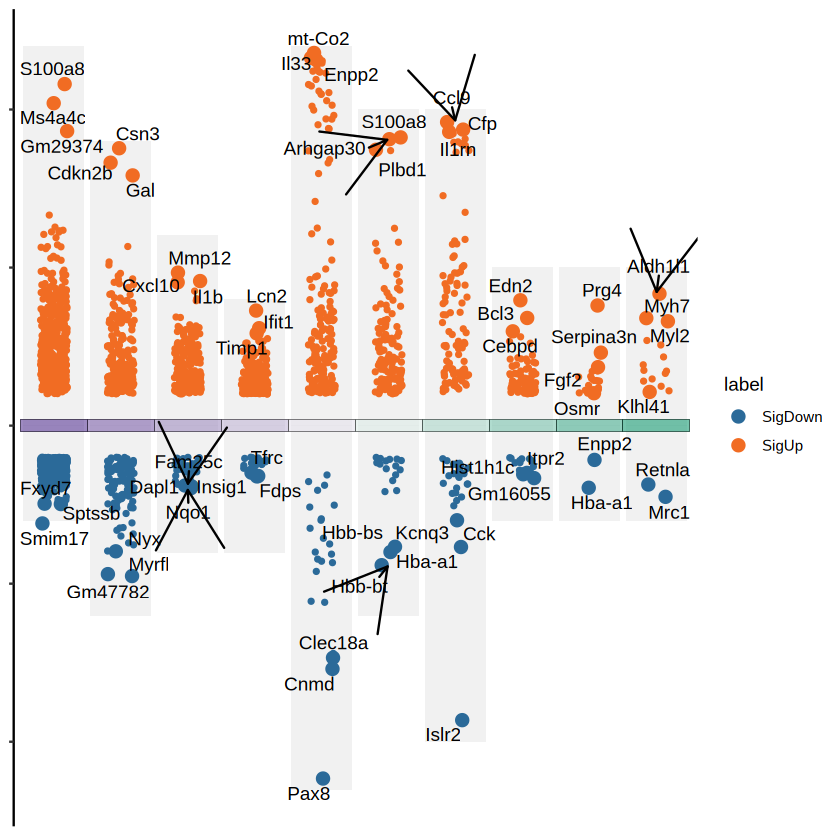

In [292]:
p6
ggsave("STST_numdeg_multi.pdf",p6,width = 7,height = 5)

In [3]:
deg2 <- readRDS("deg.RDS")